/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


N= 2, τ=0.9584, Eb=1.051391, Ergotropy=1.014536, erg/Eb=0.964946225027 Variance=5.7193620668e-01
N= 3, τ=0.9941, Eb=1.664269, Ergotropy=1.620173, erg/Eb=0.973504694726 Variance=8.7904505321e-01
N= 4, τ=1.0155, Eb=2.288325, Ergotropy=2.239382, erg/Eb=0.978611777944 Variance=1.1879410363e+00
N= 5, τ=1.0299, Eb=2.918434, Ergotropy=2.866001, erg/Eb=0.982033750351 Variance=1.4977823471e+00
N= 6, τ=1.0403, Eb=3.552231, Ergotropy=3.497159, erg/Eb=0.984496387529 Variance=1.8081903106e+00
N= 7, τ=1.0482, Eb=4.188521, Ergotropy=4.131376, erg/Eb=0.986356786863 Variance=2.1189749778e+00
N= 8, τ=1.0543, Eb=4.826039, Ergotropy=4.767250, erg/Eb=0.987818500702 Variance=2.4299543029e+00
N= 9, τ=1.0593, Eb=5.465159, Ergotropy=5.404998, erg/Eb=0.988991931309 Variance=2.7411649095e+00
N=10, τ=1.0634, Eb=6.105073, Ergotropy=6.043768, erg/Eb=0.989958333969 Variance=3.0524961209e+00
N=11, τ=1.0669, Eb=6.746064, Ergotropy=6.683770, erg/Eb=0.990765908825 Variance=3.3639729173e+00
N=12, τ=1.0698, Eb=7.387080, E

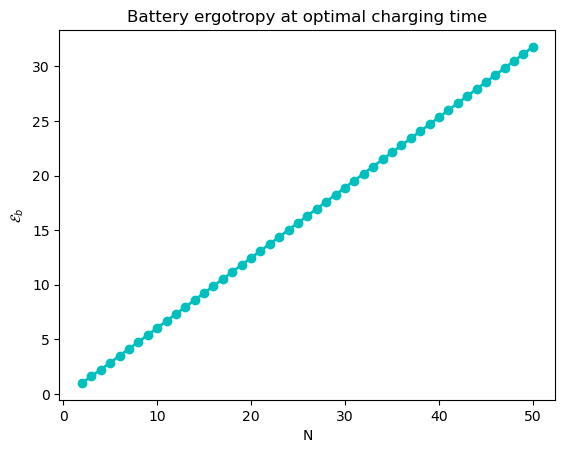

In [9]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 51, 1)
nmax = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + (g / np.sqrt(N)) * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14, nsteps=1000000)         ## ODE solver options
    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full, options=opts)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    # e_vals = np.arange(N + 1) * ω0
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB, r_vecs[i]) for i in range(len(r_vals)))
    
    ΔE2 = W_2 - (E_erg)**2
    
    ΔE = np.sqrt(ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.savefig("OP01")
plt.show()

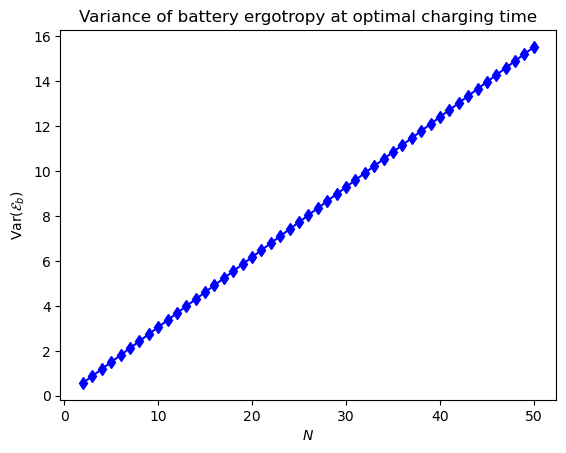

In [10]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.savefig("OP02")
plt.show()

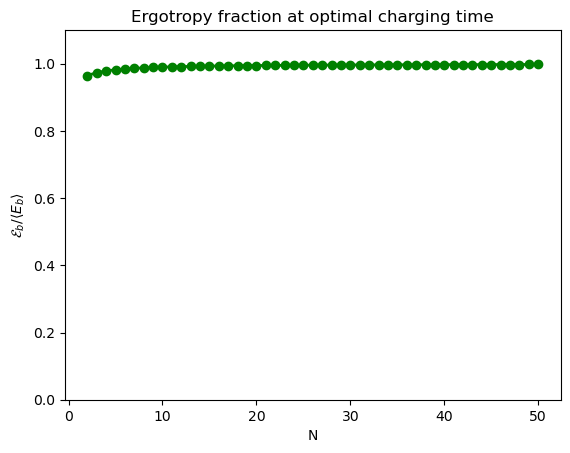

In [11]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.savefig("OP03")
plt.show()

N= 2, τ=0.9584, Relative Fluctuation =0.745429101873, Relative Fluctuation with Eb =0.719298997877
N= 3, τ=0.9941, Relative Fluctuation =0.578687422904, Relative Fluctuation with Eb =0.563354922976
N= 4, τ=1.0155, Relative Fluctuation =0.486708888473, Relative Fluctuation with Eb =0.476299050689
N= 5, τ=1.0299, Relative Fluctuation =0.427019848451, Relative Fluctuation with Eb =0.419347903249
N= 6, τ=1.0403, Relative Fluctuation =0.384509203566, Relative Fluctuation with Eb =0.378547921882
N= 7, τ=1.0482, Relative Fluctuation =0.352345040548, Relative Fluctuation with Eb =0.347537922062
N= 8, τ=1.0543, Relative Fluctuation =0.326987471131, Relative Fluctuation with Eb =0.323004273481
N= 9, τ=1.0593, Relative Fluctuation =0.306317672815, Relative Fluctuation with Eb =0.302945706831
N=10, τ=1.0634, Relative Fluctuation =0.289081138960, Relative Fluctuation with Eb =0.286178282707
N=11, τ=1.0669, Relative Fluctuation =0.274413037528, Relative Fluctuation with Eb =0.271879082520
N=12, τ=1.

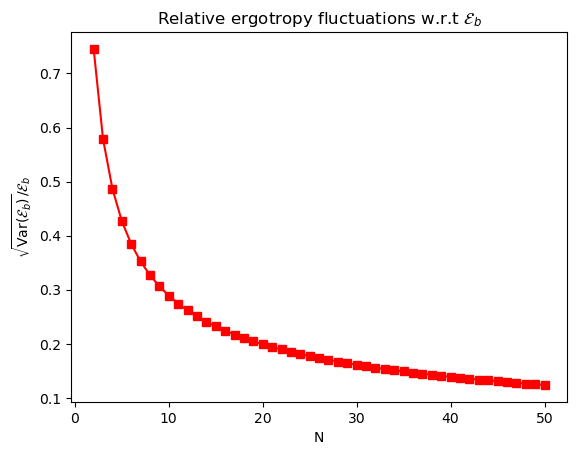

In [12]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.savefig("OP04")
plt.show()

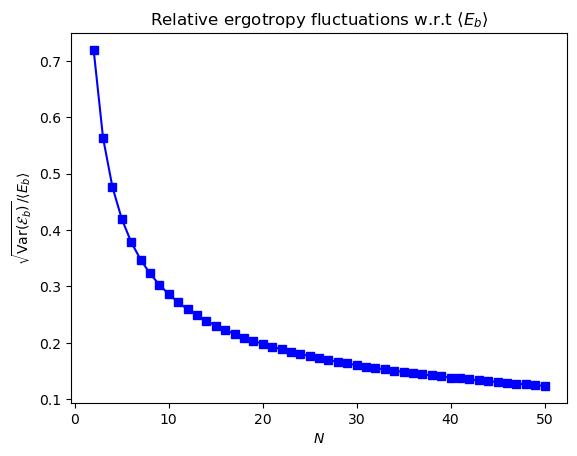

In [13]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.savefig("OP05")
plt.show()

Best fit parameters: A = -0.001660, B = 0.061022, Optimal value for alpha: 0.714927


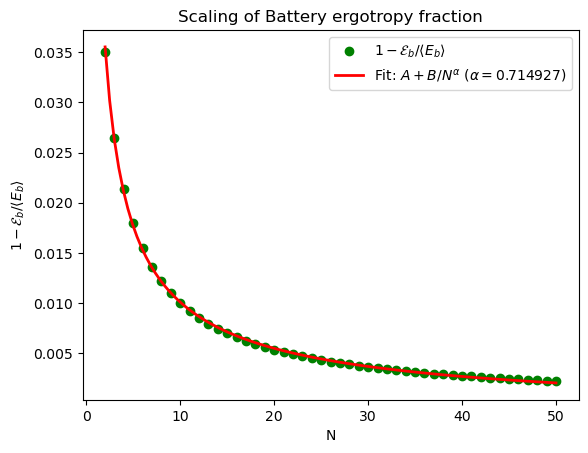

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# The fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))


y_data = 1 - np.array(E_ratio) 

# The curve fit

popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal parameters

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='g', markersize=6, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
plt.savefig("OP06")
plt.show()

Best fit parameters: A = 0.033555, B = 1.098565, Optimal value for alpha: 0.633830


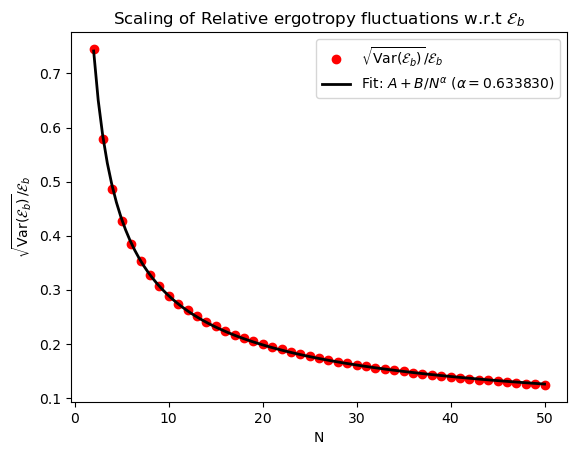

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fitting function
def asymptotic_fit(N, alpha, A, B):
    return (A + B / (N**alpha))

y_data = np.array(F_ratio) 

# The curve fit
popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
alpha_opt, A_opt, B_opt = popt

print(f"Best fit parameters: A = {A_opt:.6f}, B = {B_opt:.6f}, Optimal value for alpha: {alpha_opt:.6f}")

# A smooth curve for the fit using the optimal alpha

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, alpha_opt, A_opt, B_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='r', markersize=6, label=r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.plot(N_smooth, y_fit, '-', color='k', linewidth=2, label=rf'Fit: $A + B/N^{{\alpha}}$ ($\alpha={alpha_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Scaling of Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.legend()
plt.savefig("OP07")
plt.show()